In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

In [2]:
house_price_df = pd.read_csv(r"C:\Users\ARIO\Documents\ML_csv\house _price.csv")
house_price_df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD)
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33


In [3]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
house_price_df['Address_code'] = le.fit_transform(house_price_df["Address"])

adress_map = dict(zip(le.transform(le.classes_),le.classes_))
le.inverse_transform([1])

array(['Abbasabad'], dtype=object)

In [4]:
house_price_df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Address_code
0,63,1,True,True,True,Shahran,1.850000e+09,61666.67,156
1,60,1,True,True,True,Shahran,1.850000e+09,61666.67,156
2,79,2,True,True,True,Pardis,5.500000e+08,18333.33,117
3,95,2,True,True,True,Shahrake Qods,9.025000e+08,30083.33,152
4,123,2,True,True,True,Shahrake Gharb,7.000000e+09,233333.33,150


In [5]:
house_price_df['Parking'] = house_price_df['Parking'].astype(int)

In [6]:
house_price_df['Warehouse'] = house_price_df['Warehouse'].astype(int)

In [7]:
house_price_df['Elevator'] = house_price_df['Elevator'].astype(int)

In [8]:
house_price_df.head()

,Area,Room,Parking,Warehouse,Elevator,Address,Price,Price(USD),Address_code
0,63,1,1,1,1,Shahran,1.850000e+09,61666.67,156
1,60,1,1,1,1,Shahran,1.850000e+09,61666.67,156
2,79,2,1,1,1,Pardis,5.500000e+08,18333.33,117
3,95,2,1,1,1,Shahrake Qods,9.025000e+08,30083.33,152
4,123,2,1,1,1,Shahrake Gharb,7.000000e+09,233333.33,150


In [9]:
df = house_price_df.drop(columns=['Address'])
df.head()

,Area,Room,Parking,Warehouse,Elevator,Price,Price(USD),Address_code
0,63,1,1,1,1,1.850000e+09,61666.67,156
1,60,1,1,1,1,1.850000e+09,61666.67,156
2,79,2,1,1,1,5.500000e+08,18333.33,117
3,95,2,1,1,1,9.025000e+08,30083.33,152
4,123,2,1,1,1,7.000000e+09,233333.33,150


In [10]:
df['Area'] = df['Area'].astype(str).str.replace(',', '', regex=False).str.strip()
df['Area'] = pd.to_numeric(df['Area'], errors='coerce')

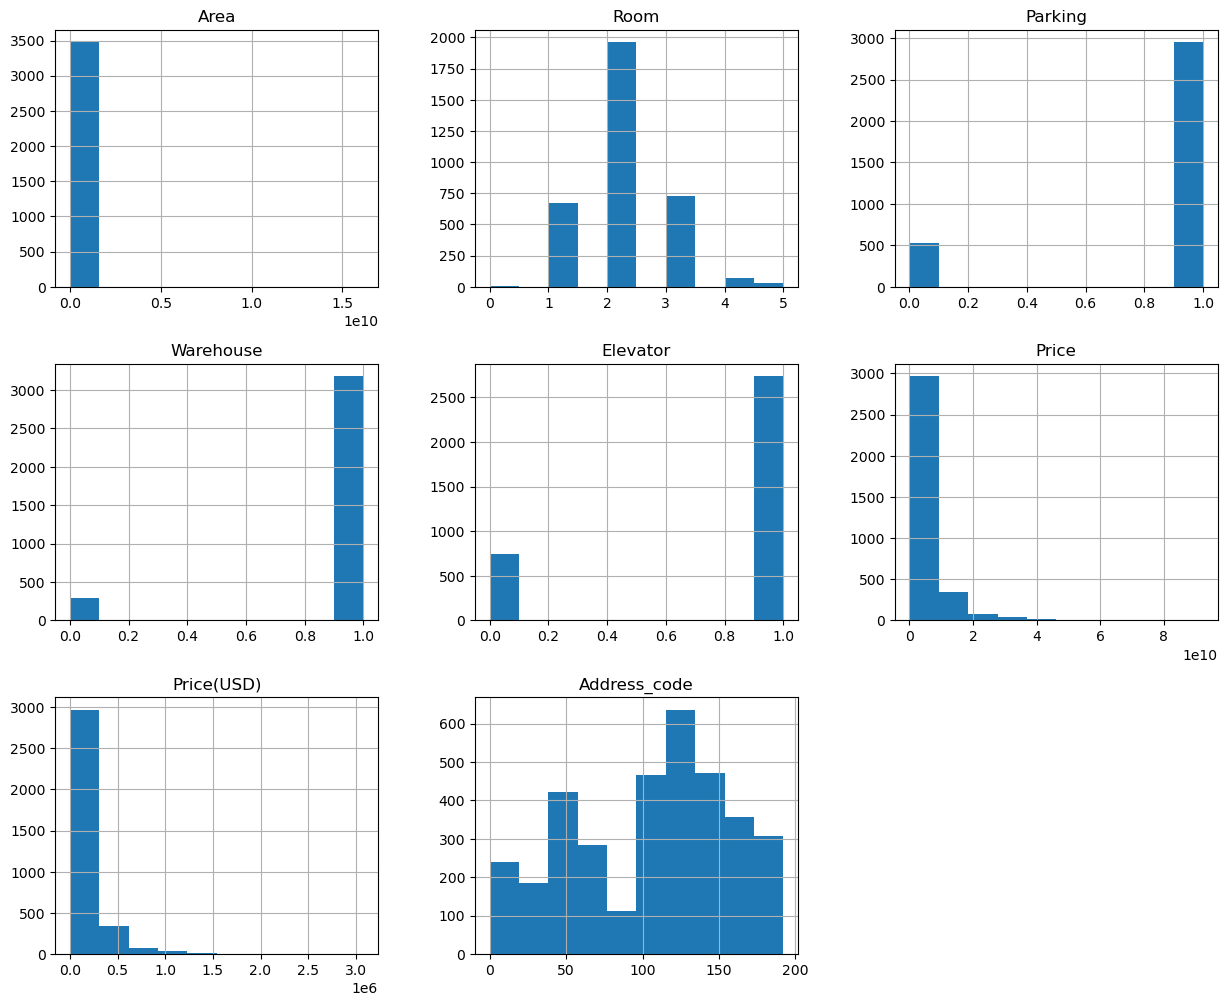

In [11]:
df.hist(figsize=(15,12))
plt.show()

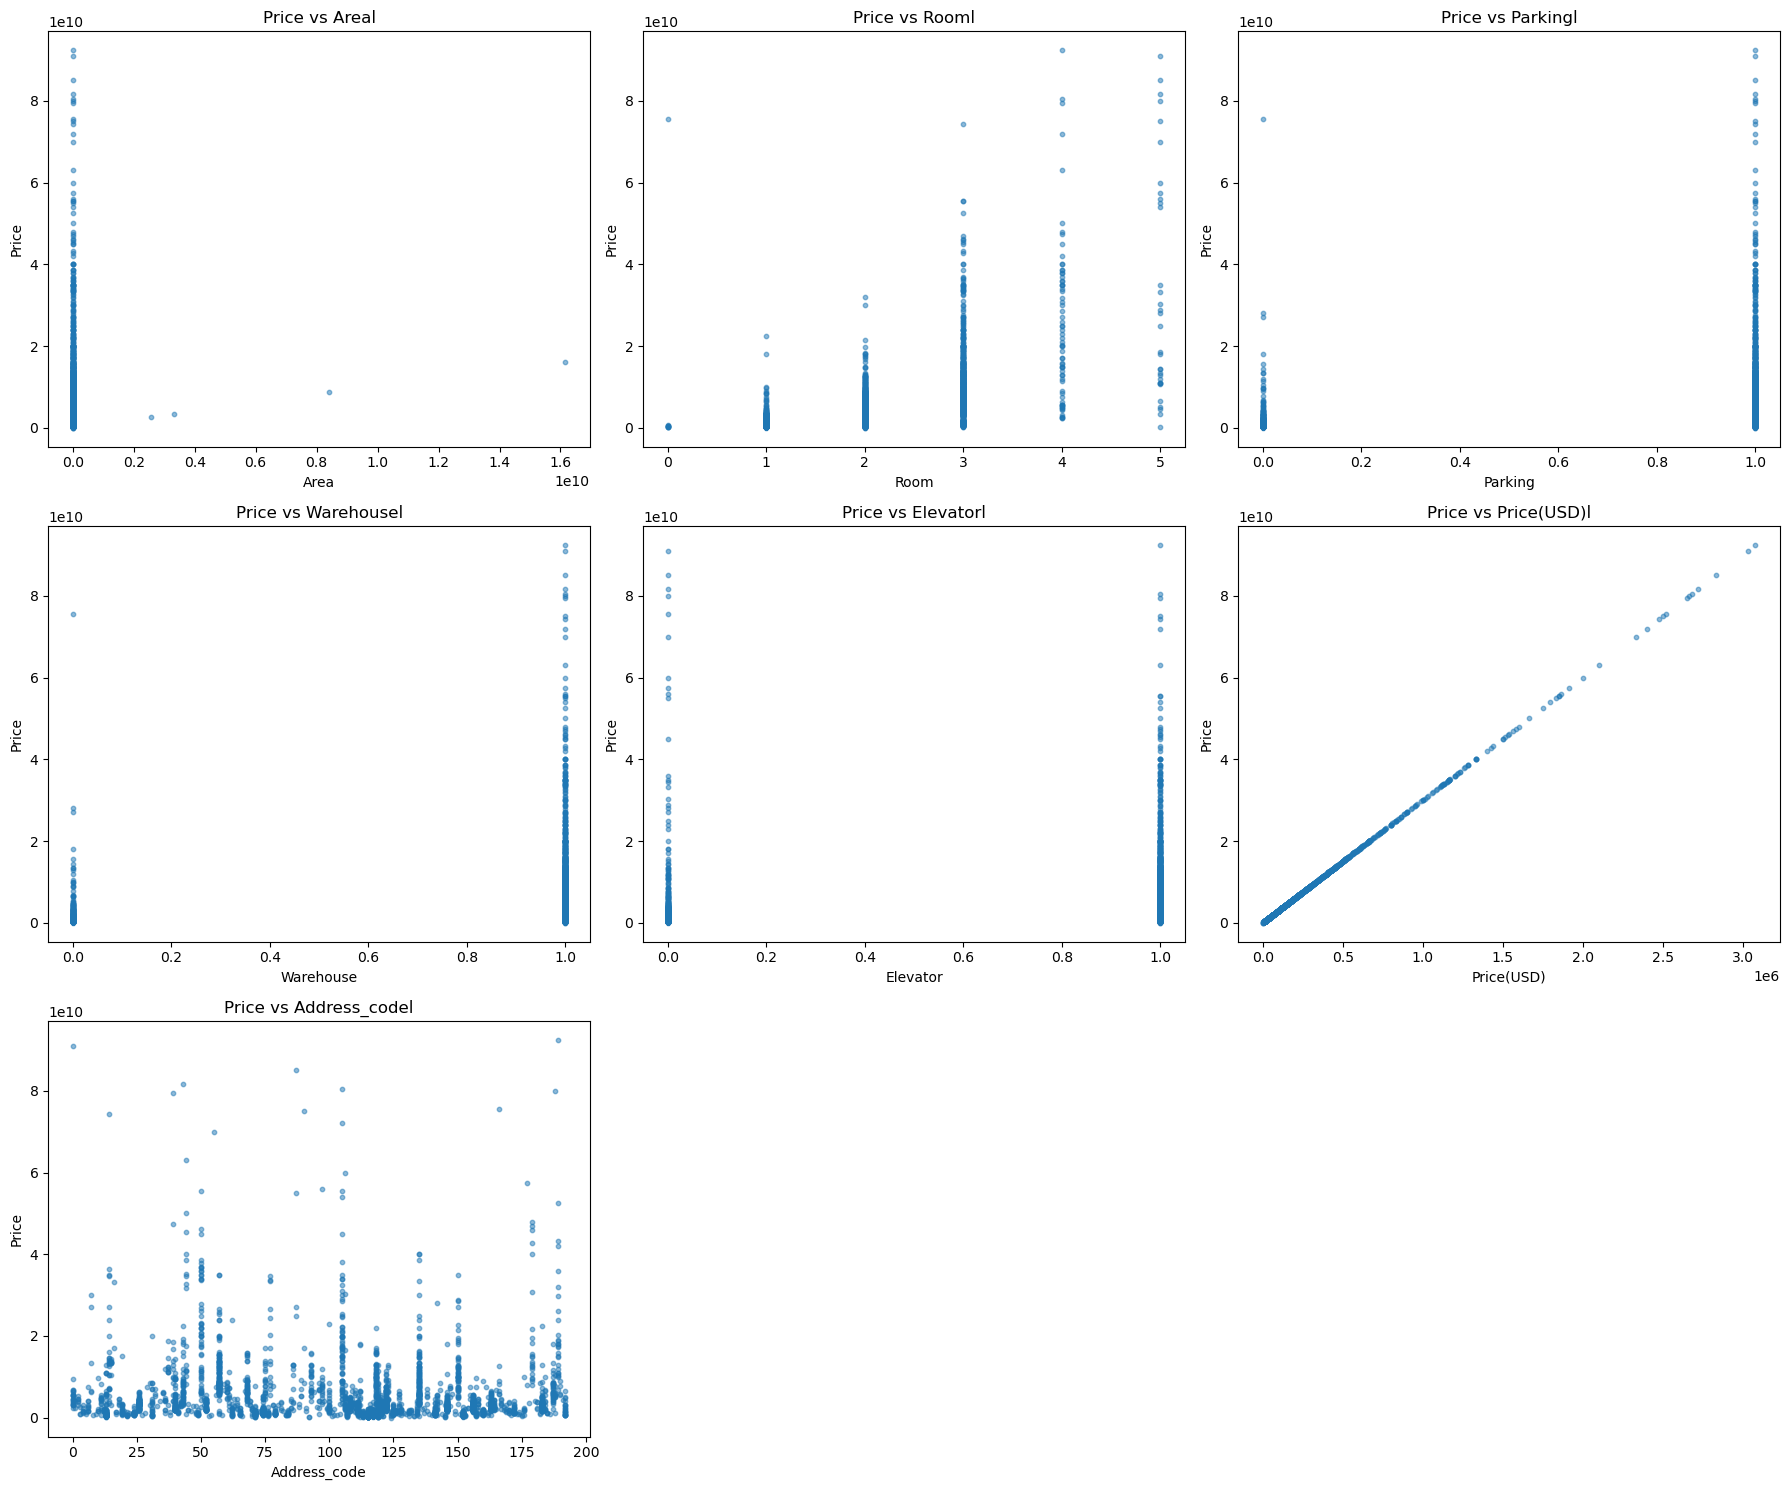

In [12]:
import matplotlib.pyplot as plt


df.columns = df.columns.str.strip()


x_columns = [col for col in df.columns if col != 'Price']


n = len(x_columns)
cols = 3
rows = (n // cols) + (1 if n % cols != 0 else 0)

fig, axes = plt.subplots(rows, cols, figsize=(18, 5*rows))
axes = axes.flatten()

for i, col in enumerate(x_columns):
    axes[i].scatter(df[col], df['Price'], alpha=0.5, s=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Price')
    axes[i].set_title(f'Price vs {col}ا')

for j in range(i+1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [13]:
msk = np.random.randn(len(df)) < 0.8
train = df[msk]
test = df[~msk]


In [14]:
from sklearn import linear_model
regr = linear_model.LinearRegression()
train_x = np.asanyarray(train[['Area','Room','Parking','Warehouse','Elevator', 'Address_code']])
train_y = np.asanyarray(train[['Price']])

In [15]:
regr.fit(train_x , train_y)
print( 'coef_',regr.coef_)
print('intercept_' , regr.intercept_)

coef_ [[ 2.77319016e-01  5.66088174e+09  4.63904016e+08  4.89341960e+08
   1.28990348e+08 -6.55443942e+06]]
intercept_ [-6.71808368e+09]


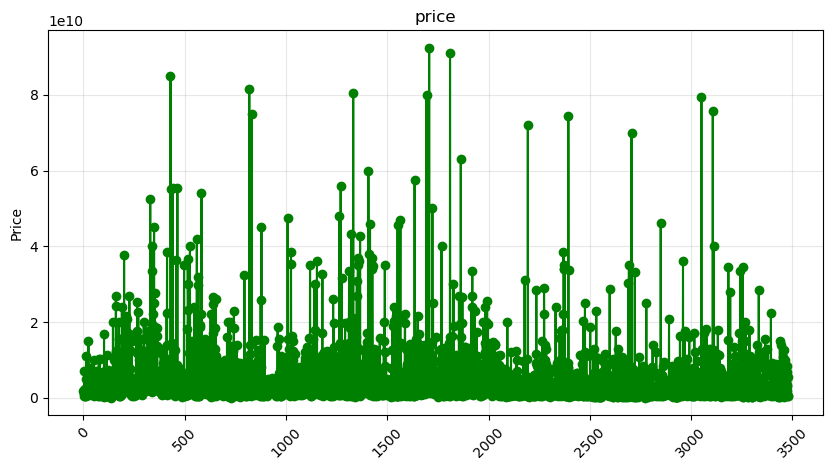

In [18]:
plt.figure(figsize=(10, 5))
plt.plot(df.index, df['Price'], 'o-', color='green')

plt.ylabel('Price')
plt.title('price')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.show()

In [19]:
y_hat = regr.predict(test[['Area','Room','Parking','Warehouse','Elevator', 'Address_code']])
x = np.asanyarray(test[['Area','Room','Parking','Warehouse','Elevator', 'Address_code']])
y = np.asanyarray(test['Price'])
print(np.mean((y_hat - y)**2))
print(regr.score(x , y))

1.0746761064469257e+20
0.3259198273364897


C:\Users\ARIO\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(
